In [5]:
import os                          # for working with files
import numpy as np                 # for numerical data
import tensorflow as tf            # for machine learning
import pandas as pd                # for working with dataframes
from tensorflow import keras       # for neural network
import matplotlib.pyplot as plt    # for plotting info on graph
from PIL import Image              # for image processing in python
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

In [6]:
dataset = 'New Plant Disease Dataset'
train_dir = os.path.join(dataset , 'train')
val_dir = os.path.join(dataset , 'valid')
diseases = os.listdir(train_dir)
print(diseases)

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___healthy', 'Corn_(maize)___Northern_Leaf_Blight', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___healthy', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight', 'Strawberry___healthy', 'Strawberry___Leaf_scorch', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___healthy', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_mosaic_virus', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus']


In [35]:
# Reload the dataset to access class names
train_unmapped = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(224, 224),
    batch_size=32
)

# Get class names
class_names = train_unmapped.class_names
num_classes = len(class_names)
print(f"Total classes: {num_classes}")

Found 118730 files belonging to 32 classes.
Total classes: 32


In [36]:
IMG_SIZE = (224 , 224)
BATCH_SIZE = 32

train = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels = 'inferred',
    label_mode = 'int',
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE
)

valid = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    labels =  'inferred',
    label_mode = 'int',
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE
)

normalization_layer = tf.keras.layers.Rescaling(1./255)

train = train.map(lambda x , y : (normalization_layer(x) , y))
valid = valid.map(lambda x , y : (normalization_layer(x) , y))


Found 118730 files belonging to 32 classes.
Found 29714 files belonging to 32 classes.


In [38]:
from tensorflow.keras import layers , models

def create_cnn_model(input_shape = (224 , 224 , 3) , num_classes = len(diseases)):
    model = models.Sequential()

    model.add(layers.Conv2D(32 , (3, 3) , activation = 'relu' , input_shape = input_shape))
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Conv2D(64 , (3 ,3) , activation = 'relu'))
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Conv2D(128 , (3 ,3) , activation = 'relu'))
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Conv2D(256 , (3 ,3) , activation = 'relu'))
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Flatten())
    model.add(layers.Dense(512 , activation = 'relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(num_classes, activation = 'softmax'))

    model.compile(optimizer = 'adam' , 
                  loss = 'sparse_categorical_crossentropy' , 
                  metrics = ['accuracy'])
    
    return model

cnn_model = create_cnn_model()
cnn_model.summary()




c:\Users\KIIT\Desktop\AI-Climate-Crops\env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,874,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │        16,416 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,279,712 (73.55 MB)

 Trainable params: 19,279,712 (73.55 MB)

 Non-trainable params: 0 (0.00 B)

In [39]:
history = cnn_model.fit(
    train , 
    validation_data = valid,
    epochs = 6 ,
    batch_size = 32


    
)

Epoch 1/6


3711/3711 ━━━━━━━━━━━━━━━━━━━━ 3273s 881ms/step - accuracy: 0.5961 - loss: 1.3558 - val_accuracy: 0.9206 - val_loss: 0.2375
Epoch 2/6
3711/3711 ━━━━━━━━━━━━━━━━━━━━ 3240s 873ms/step - accuracy: 0.9071 - loss: 0.2916 - val_accuracy: 0.9453 - val_loss: 0.1700
Epoch 3/6
3711/3711 ━━━━━━━━━━━━━━━━━━━━ 3871s 1s/step - accuracy: 0.9438 - loss: 0.1794 - val_accuracy: 0.9485 - val_loss: 0.1722
Epoch 4/6
3711/3711 ━━━━━━━━━━━━━━━━━━━━ 5313s 1s/step - accuracy: 0.9578 - loss: 0.1297 - val_accuracy: 0.9435 - val_loss: 0.1992
Epoch 5/6
3711/3711 ━━━━━━━━━━━━━━━━━━━━ 3248s 875ms/step - accuracy: 0.9666 - loss: 0.1065 - val_accuracy: 0.9601 - val_loss: 0.1428
Epoch 6/6
3711/3711 ━━━━━━━━━━━━━━━━━━━━ 3252s 876ms/step - accuracy: 0.9709 - loss: 0.0967 - val_accuracy: 0.9573 - val_loss: 0.1695


In [43]:
cnn_model.save("plant_disease_model1.h5")

In [7]:
from tensorflow.keras.models import load_model

# Path to your saved model
model_path = 'plant_disease_model1.h5'

# Load the model
cnn_model = load_model(model_path)

print("Model loaded successfully!")

Model loaded successfully!


In [9]:
from tensorflow import keras 
image = keras.preprocessing.image
import numpy as np

def predict_image(img_path , model):
    img = image.load_img(img_path , target_size=(224 , 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array , axis = 0)

    prediction = model.predict(img_array)
    class_idx = np.argmax(prediction)

    predicted_label = diseases[class_idx]
     # Split the label into crop and disease
    crop, disease = predicted_label.split("___")
    
    # Remove underscores from disease name
    disease = disease.replace("_", " ")
    
    # Store them in variables
    print(f"Predicted Crop: {crop}")
    print(f"Predicted Disease: {disease}")

    return crop, disease


    


img_path = r"C:\Users\KIIT\Desktop\AI-Climate-Crops\test\AppleCedarRust2.JPG"
crop , disease = predict_image(img_path , cnn_model)
print("Crop:", crop)
print("Disease:", disease)

img_path = r"C:\Users\KIIT\Desktop\AI-Climate-Crops\test\TomatoEarlyBlight5.JPG"
crop, disease = predict_image(img_path, cnn_model)
print("Crop:", crop)
print("Disease:", disease)


img_path = r"C:\Users\KIIT\Desktop\AI-Climate-Crops\test\CornCommonRust3.JPG"
crop, disease = predict_image(img_path, cnn_model)
print("Crop:", crop)
print("Disease:", disease)


img_path = r"C:\Users\KIIT\Desktop\AI-Climate-Crops\test\PotatoEarlyBlight2.JPG"
crop, disease = predict_image(img_path, cnn_model)
print("Crop:", crop)
print("Disease:", disease)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Predicted Crop: Apple
Predicted Disease: Cedar apple rust
Crop: Apple
Disease: Cedar apple rust
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Predicted Crop: Tomato
Predicted Disease: Early blight
Crop: Tomato
Disease: Early blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Predicted Crop: Corn_(maize)
Predicted Disease: Common rust 
Crop: Corn_(maize)
Disease: Common rust 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Predicted Crop: Potato
Predicted Disease: Early blight
Crop: Potato
Disease: Early blight


In [46]:
import os
from tensorflow import keras 
image = keras.preprocessing.image
import numpy as np

# Path to the test directory
dataset = r"C:\Users\KIIT\Desktop\AI-Climate-Crops\test"
test_dir = os.path.join(dataset)

# Load all images from the test folder
def load_test_images(test_dir, img_size=(224, 224)):
    images = []
    image_names = []
    
    for img_name in os.listdir(test_dir):
        img_path = os.path.join(test_dir, img_name)
        
        # Load and preprocess the image
        img = image.load_img(img_path, target_size=img_size)
        img_array = image.img_to_array(img) / 255.0  # Normalize
        images.append(img_array)
        image_names.append(img_name)

    return np.array(images), image_names

# Load test images
test_images, image_names = load_test_images(test_dir)
print(f'Loaded {len(test_images)} test images.')

Loaded 34 test images.


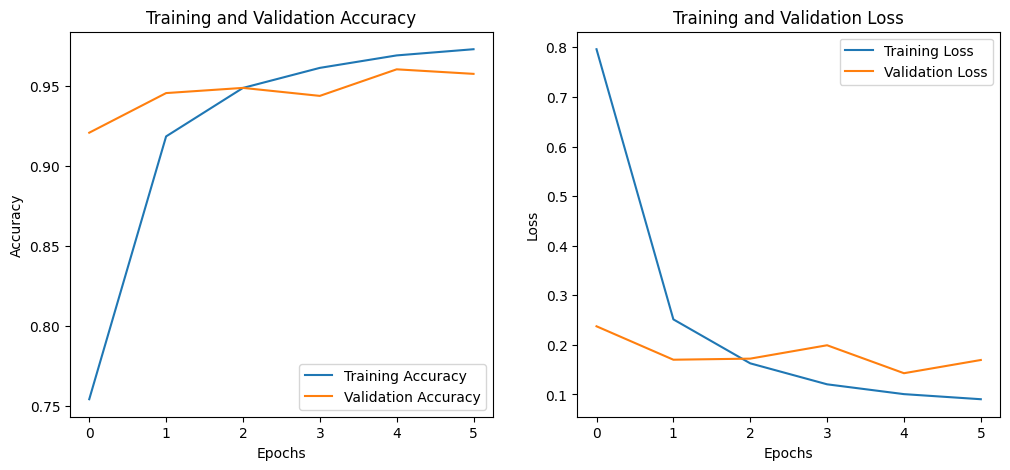

In [ ]:
c

In [11]:
import requests
API_KEY = "bfc1a21674f2fe9623f21598d0f5398b"

sensitivity_thresholds = {
    'Potato': {'Late_blight': 2, 'Early_blight': 1},
    'Corn_(maize)': {'Common_rust_': 1, 'Northern_Leaf_Blight': 2},
    'Tomato': {'Tomato_mosaic_virus': 3, 'Tomato_Yellow_Leaf_Curl_Virus': 2, 'Bacterial_spot': 1},
    'Apple': {'Apple_scab': 2, 'Cedar_apple_rust': 1},
    'Grape': {'Black_rot': 2, 'Esca_(Black_Measles)': 3},
    'Orange': {'Haunglongbing_(Citrus_greening)': 3},
    'Strawberry': {'Leaf_scorch': 2},
    'Peach': {'Leaf_Mold': 1},
    'Cherry_(including_sour)': {'Leaf_blight_(Isariopsis_Leaf_Spot)': 1},
    'Pepper,_bell': {'Bacterial_spot': 1}
}

# Get location from IP
def get_ip_location():
    try:
        ip_response = requests.get("https://ipinfo.io").json()
        loc = ip_response.get('loc', '0,0').split(',')
        lat, lon = map(float, loc)
        return lat, lon
    except Exception as e:
        print(f"⚠️ Error fetching IP location: {e}")
        return None, None

# Fetch weather data
def get_weather(lat, lon):
    try:
        url = f"http://api.openweathermap.org/data/2.5/weather?lat={lat}&lon={lon}&appid={API_KEY}&units=metric"
        response = requests.get(url).json()

        temperature = response.get('main', {}).get('temp', None)
        humidity = response.get('main', {}).get('humidity', None)
        weather_desc = response.get('weather', [{}])[0].get('description', 'N/A')

        if temperature is None or humidity is None:
            print("⚠️ Incomplete weather data received.")
            return None, None, weather_desc

        print(f"\n🌡️  Temperature: {temperature:.1f}°C")
        print(f"💧  Humidity: {humidity}%")
        print(f"🌦️  Weather: {weather_desc.capitalize()}")


        return temperature, humidity, weather_desc

    except Exception as e:
        print(f"⚠️ Error fetching weather: {e}")
        return None, None, 'N/A'

# Calculate severity score based on weather
def calculate_severity_score(temperature, humidity, weather_desc):
    if temperature is None or humidity is None:
        return 0

    severity_score = 0

    # Temperature-based scoring
    if temperature < 10 or temperature > 35:
        severity_score += 3
    elif 10 <= temperature < 20 or 30 <= temperature <= 35:
        severity_score += 2
    else:
        severity_score += 1
    
    # Humidity-based scoring
    if humidity > 80:
        severity_score += 3
    elif 50 <= humidity <= 80:
        severity_score += 2
    else:
        severity_score += 1

    # Weather condition scoring
    weather_conditions = ['rain', 'storm', 'snow', 'drizzle', 'thunderstorm', 'hail', 'fog']
    if any(condition in weather_desc.lower() for condition in weather_conditions):
        severity_score += 3

    return severity_score

# Get severity risk for each crop-disease pair
def get_severity_score(crop, disease, severity_score):
    if crop in sensitivity_thresholds and disease in sensitivity_thresholds[crop]:
        threshold = sensitivity_thresholds[crop][disease]

        if severity_score >= threshold + 1:
            return "🔴 High Risk"
        elif severity_score == threshold:
            return "🟠 Moderate Risk"
        else:
            return "🟢 Low Risk"
    else:
        return "❓ No Disease"

# Display results in a structured format
def display_results(severity_score):
    print("\n🌾 Crop-Disease Risk Analysis:")
    print("=" * 50)
    
    for crop, diseases in sensitivity_thresholds.items():
        print(f"\n🌿 {crop}:")
        for disease in diseases:
            risk_level = get_severity_score(crop, disease, severity_score)
            print(f"   - {disease.replace('_', ' ')}: {risk_level}")
    
    print("\n" + "=" * 50)

# Main Execution
lat, lon = get_ip_location()

if lat and lon:
    temp, humidity, weather_desc = get_weather(lat, lon)

    if temp is not None and humidity is not None:
        # Calculate severity score
        severity_score = calculate_severity_score(temp, humidity, weather_desc)
        print(f"\n🔥 Calculated Severity Score: {severity_score}")
        
        # Display refined results
        display_results(severity_score)
    else:
        print("\n⚠️ Weather data is incomplete. Cannot assess risk accurately.")
else:
    print("\n⚠️ Could not determine location.")



🌡️  Temperature: 37.0°C
💧  Humidity: 28%
🌦️  Weather: Broken clouds

🔥 Calculated Severity Score: 4

🌾 Crop-Disease Risk Analysis:

🌿 Potato:
   - Late blight: 🔴 High Risk
   - Early blight: 🔴 High Risk

🌿 Corn_(maize):
   - Common rust : 🔴 High Risk
   - Northern Leaf Blight: 🔴 High Risk

🌿 Tomato:
   - Tomato mosaic virus: 🔴 High Risk
   - Tomato Yellow Leaf Curl Virus: 🔴 High Risk
   - Bacterial spot: 🔴 High Risk

🌿 Apple:
   - Apple scab: 🔴 High Risk
   - Cedar apple rust: 🔴 High Risk

🌿 Grape:
   - Black rot: 🔴 High Risk
   - Esca (Black Measles): 🔴 High Risk

🌿 Orange:
   - Haunglongbing (Citrus greening): 🔴 High Risk

🌿 Strawberry:
   - Leaf scorch: 🔴 High Risk

🌿 Peach:
   - Leaf Mold: 🔴 High Risk

🌿 Cherry_(including_sour):
   - Leaf blight (Isariopsis Leaf Spot): 🔴 High Risk

🌿 Pepper,_bell:
   - Bacterial spot: 🔴 High Risk



In [49]:
import pandas as pd

df = pd.read_csv('updated_crop_disease_genetic_modifications.csv' , encoding='latin-1')

column1 = df['Crop']
column2 = df['Disease']
column3 = df['Genetic Modification']
column4 = df['Efficiency of the Modification (%)'] 

print(column1)
print(column2)
print(column3)
print(column4)

0        Potato
1        Potato
2        Potato
3        Potato
4        Potato
        ...    
58    Raspberry
59    Raspberry
60       Pepper
61       Pepper
62       Pepper
Name: Crop, Length: 63, dtype: object
0        Late blight
1        Late blight
2        Late blight
3       Early blight
4       Early blight
           ...      
58       Target Spot
59       Target Spot
60    Bacterial spot
61    Bacterial spot
62    Bacterial spot
Name: Disease, Length: 63, dtype: object
0     CRISPR-Cas9 to target genes for resistance to ...
1     Genetic engineering to overexpress the Rpi-blb...
2     Introduction of resistance from wild Solanum s...
3     Transgenic potato expressing Bacillus thuringi...
4     Engineering for resistance to Alternaria solan...
                            ...                        
58    Expression of pathogen-induced proteins to inc...
59    Genetic modification to enhance phenolic compo...
60    Genetic modification to express Xanthomonas re...
61    Engi

In [50]:
from sklearn.preprocessing import LabelEncoder
crop_en = LabelEncoder()
disease_en = LabelEncoder()
genetic_en = LabelEncoder()

df.loc[:,'Crop_Encoded'] = crop_en.fit_transform(df['Crop'])
df.loc[:,'Disease_Encoded'] = disease_en.fit_transform(df['Disease'])
target_genetic_modification = genetic_en.fit_transform(df['Genetic Modification'])

In [51]:
X = df[['Crop_Encoded' , 'Disease_Encoded']]
y_mod = target_genetic_modification
y_eff = df[['Efficiency of the Modification (%)']]

In [52]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train_mod , y_test_mod , y_train_eff , y_test_eff = train_test_split(X , y_mod , y_eff , test_size = 0.2 , random_state = 42)

if isinstance(y_train_eff, pd.DataFrame):
    y_train_eff = y_train_eff.iloc[:, 0]

if isinstance(y_test_eff, pd.DataFrame):
    y_test_eff = y_test_eff.iloc[:, 0]

# Convert percentage strings to float values
y_train_eff = y_train_eff.astype(str).str.replace('%', '').astype(float) / 100
y_test_eff = y_test_eff.astype(str).str.replace('%', '').astype(float) / 100

In [53]:
from sklearn.ensemble import RandomForestClassifier , RandomForestRegressor

model_modification = RandomForestClassifier(random_state=42)
model_modification.fit(X_train , y_train_mod)

RandomForestClassifier(random_state=42)

In [54]:

model_efficiency = RandomForestRegressor(random_state=42)
model_efficiency.fit(X_train , y_train_eff)

RandomForestRegressor(random_state=42)

In [55]:
crop_input = crop 
disease_input = disease
if crop_input in crop_en.classes_ and disease_input in disease_en.classes_:
   
   input_data = pd.DataFrame({'Crop': [crop_input], 'Disease': [disease_input]})
   input_data['Crop_Encoded'] = crop_en.transform(input_data['Crop'])
   input_data['Disease_Encoded'] = disease_en.transform(input_data['Disease'])

   predict_mod = model_modification.predict(input_data[['Crop_Encoded', 'Disease_Encoded']])
   predicted_modification = genetic_en.inverse_transform(predict_mod)

   print(predicted_modification)
else:
    print("Invalid crop or disease input.")

['Engineering for resistance to Alternaria solani using synthetic biology']


In [58]:
predicted_modification_encoded = model_modification.predict(input_data[['Crop_Encoded', 'Disease_Encoded']])[0]
predicted_modification = genetic_en.inverse_transform([predicted_modification_encoded])[0]

efficiency_row = df[(df['Crop'] == crop_input) & (df['Disease'] == disease_input) & (df['Genetic Modification'] == predicted_modification)]

if not efficiency_row.empty:
    predicted_efficiency = efficiency_row['Efficiency of the Modification (%)'].values[0]
else:
    predicted_efficiency = model_efficiency.predict(input_data[['Crop_Encoded', 'Disease_Encoded']])[0]

print(f"Predicted Genetic Modification for {crop_input} and {disease_input}: {predicted_modification}")
predicted_efficiency = predicted_efficiency.strip('%')  # Remove the percentage sign
predicted_efficiency = float(predicted_efficiency)  # Convert to float
print(f"Efficiency of Genetic Modification: {predicted_efficiency:.2f}%")



Predicted Genetic Modification for Potato and Early blight: Engineering for resistance to Alternaria solani using synthetic biology
Efficiency of Genetic Modification: 78.00%
